# Spectral calibration: miniPAR channels → spectrum, referenced to the LR1-B

Implements the chain from the ams reference workbook **AS7341_AD000198_3-00.xlsx**, which is
the worked implementation of AN000633:

```
Data Sensor (Corr) = Corr_Factor × ( Basic_Counts − Offset )        (workbook cell F10)
Reconstructed spectrum = CM · Data Sensor (Corr)                    (721 × 10 matrix, 1 nm)
```

so: **§2.1 basic counts → §2.2 per-channel offset → §2.4 per-channel correction vector →
§2.5 spectral reconstruction matrix**. PAR is not computed here.

**No NIR correction.** The ams workbook contains none — no `Sλ_scaling`, no `Sλ_ratio_NIR`, no
Eq. 3–9 anywhere in it. AN000633 §2.3 is a situational fallback for unstable NIR without a
matrix; the reconstruction matrix's negative lobes (e.g. F2 = −0.0339 and Clear = −0.0070 at
380 nm) already subtract the out-of-band leakage. Applying both would double-correct.

## Three things established before writing this

1. **The calibration file is `N 3163.clbr`, not `N 1370.clbr`.** The LR1-B writes its own
   wavelength grid into every saved spectrum, and only one `.clbr` reproduces it:

   | file | grid | max Δλ vs data |
   |---|---|---|
   | N 1370 | 288.2–1008.9 nm | 11.218 nm |
   | N 3161 | 297.0–1004.6 nm | 12.935 nm |
   | N 3162 | 292.1–1000.9 nm | 16.618 nm |
   | **N 3163** | **296.9–1017.5 nm** | **0.0000 nm** |

   `N 1370` would apply an irradiance curve shifted by ~11 nm, silently. The notebook
   auto-selects by grid match and asserts, rather than trusting a filename.

2. **Basic-count units differ by 1000×.** ams divides by integration time in **milliseconds** —
   AN000633 Fig. 3 gives `1236 / (512 × 182) = 0.013264` — while miniPAR's firmware divisor is
   `gain × (ATIME+1) × (ASTEP+1) × 2.78e-6`, i.e. **seconds**. The workbook's offsets and its CM
   are in the ms convention, so this notebook works there throughout.

3. **The offsets are ams typicals, not measured.** This dataset carries no dark capture, and the
   offset cannot be recovered from it retrospectively — it is ~10⁻⁵ of the signal and is swamped
   by light-model error. `OFFSET_BASIC` below is the workbook's own example vector and is a
   placeholder: replace it with a measured dark sweep when one exists.

In [2]:
import glob, os, sys
from pathlib import Path

import numpy as np
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import lr1b

CH = ['f1_415', 'f2_445', 'f3_480', 'f4_515', 'f5_555',
      'f6_590', 'f7_630', 'f8_680', 'clear', 'nir']

CLBR_DIR = Path(os.environ.get('LR1B_CLBR_DIR', r'C:/Users/LudovicoCaracciolo/OneDrive - '
                               r'Stichting Jan IngenHousz Institute/Projects/0.3 Various/LR1-B software'))
def _first(paths, test):
    """First existing candidate. An unset env var must not resolve to Path('.')."""
    for s in paths:
        if not s:
            continue
        q = Path(s)
        if test(q):
            return q
    raise FileNotFoundError('none of these exist: ' + ', '.join(str(s) for s in paths if s))

XLSX = _first([os.environ.get('AMS_XLSX'),
               Path.cwd().parent / 'Firmware/docs/AS7341_AD000198_3-00.xlsx',
               Path.home() / 'Documents/Git-repo/miniPar/Firmware/docs/AS7341_AD000198_3-00.xlsx'],
              lambda q: q.is_file())
DATA = _first([os.environ.get('MINIPAR_DATA_DIR'),
               Path.cwd() / 'data', Path.cwd().parent / 'data'],
              lambda q: (q / 'multi_par_spec_lr1b.csv').exists())
print('xlsx:', XLSX)
print('data:', DATA)

df = pd.read_csv(DATA / 'multi_par_spec_lr1b.csv')
grid = np.loadtxt(DATA / 'lr1b_spectra' / os.path.basename(df.lr1b_spectrum_file.iloc[0]))[:, 0]
print('rows %d | captures %d | devices %d | tags %d | PAR %.1f-%.1f'
      % (len(df), df.measurement.nunique(), df.miniPAR.nunique(),
         df.metadata.nunique(), df.tia_par.min(), df.tia_par.max()))

# --- pick the .clbr by wavelength-grid match, never by filename ------------
cands = []
for p in sorted(CLBR_DIR.glob('*.clbr')):
    c = lr1b.Calibration.from_file(str(p))
    w = np.sort(c.wavelengths)
    d = float(np.max(np.abs(w - grid))) if len(w) == len(grid) else np.inf
    cands.append((d, p, c))
cands.sort(key=lambda t: t[0])
display(pd.DataFrame([{'file': p.name, 'serial': c.serial,
                       'span_nm': '%.1f-%.1f' % (c.wavelengths.min(), c.wavelengths.max()),
                       'max_dlambda_nm': round(d, 4), 'irradiance': c.has_irradiance}
                      for d, p, c in cands]).set_index('file'))

gap, CLBR_PATH, cal = cands[0]
assert gap < 1e-6, 'no .clbr reproduces the data wavelength grid (best %.4f nm)' % gap
print('\nusing %s  (serial %s, grid match %.1e nm)' % (CLBR_PATH.name, cal.serial, gap))

order = np.argsort(cal.wavelengths)          # device order is descending; files are ascending
irr_a, prnu_a = cal.irr_norm[order], cal.prnu_norm[order]
ok = irr_a > 0
print('pixels with irradiance calibration: %d/%d  (%.1f-%.1f nm)'
      % (ok.sum(), ok.size, grid[ok].min(), grid[ok].max()))

xlsx: C:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\Firmware\docs\AS7341_AD000198_3-00.xlsx
data: c:\Users\LudovicoCaracciolo\.traycer\worktrees\jan-ingenhousz-institute__minipar\traycer-minipar-cosmic-elk\Scripts\data
rows 195 | captures 65 | devices 3 | tags 14 | PAR 3.7-1900.6


,serial,span_nm,max_dlambda_nm,irradiance
file,,,,
N 3163.clbr,3163,296.9-1017.5,0.000,True
N 1370.clbr,1370,288.2-1008.9,11.218,True
N 3161.clbr,3161,297.0-1004.6,12.935,True
N 3162.clbr,3162,292.1-1000.9,16.618,True



using N 3163.clbr  (serial 3163, grid match 0.0e+00 nm)
pixels with irradiance calibration: 3648/3648  (296.9-1017.5 nm)


## The published correction values

From sheet `used Correction Values`: the Golden-Device spectral reconstruction matrix (1 nm,
380–1100 nm, one column per channel) and the example offset vector.

In [3]:
ws = openpyxl.load_workbook(XLSX, data_only=True)['used Correction Values']
rows = []
for r in range(6, ws.max_row + 1):
    v = [ws.cell(r, c).value for c in range(1, 12)]          # A = WV, B..K = F1..NIR
    if all(isinstance(x, (int, float)) for x in v):
        rows.append(v)
cm = np.array(rows, float)
cm_wv, CM = cm[:, 0], cm[:, 1:]                              # (721,), (721, 10)
assert CM.shape[1] == len(CH)
print('CM %s, %g-%g nm, step %g nm' % (CM.shape, cm_wv.min(), cm_wv.max(), cm_wv[1] - cm_wv[0]))

# Workbook 'Offset, measured with sensor' (row 15, cols O..X) — ams units, i.e. t_int in ms.
OFFSET_BASIC = np.array([ws.cell(15, c).value for c in range(15, 25)], float)
print('offset vector (ams units):', np.array2string(OFFSET_BASIC, precision=6))
print('  -> in miniPAR basic counts (x1000):',
      np.array2string(OFFSET_BASIC * 1000, precision=2))

CM (721, 10), 380-1100 nm, step 1 nm
offset vector (ams units): [0.00197  0.007249 0.003194 0.001315 0.001468 0.001858 0.001763 0.005217
 0.003    0.001   ]
  -> in miniPAR basic counts (x1000): [1.97 7.25 3.19 1.31 1.47 1.86 1.76 5.22 3.   1.  ]


## §2.1 Basic counts, then §2.2 offset

`gain` in the CSV is the AS7341 **register index**, not the multiplier — firmware
`gainRegToMultiplier()` maps `0 → 0.5×`, else `1 << (reg-1)`. Using the raw index would divide
by zero on register 0 and be wrong by up to 51× elsewhere.

In [4]:
def gain_multiplier(reg):
    return 0.5 if reg == 0 else float(1 << (int(reg) - 1))

# t_int in MILLISECONDS -> the ams basic-count convention the workbook's values assume.
gt_ms = df.gain.map(gain_multiplier) * (df.aint + 1) * (df.astep + 1) * 2.78e-3
basic = df[CH].to_numpy(float) / gt_ms.to_numpy()[:, None]           # §2.1
sensor = np.clip(basic - OFFSET_BASIC, 0.0, None)                    # §2.2

print('gain registers present: %s -> multipliers %s'
      % (sorted(df.gain.unique()), [gain_multiplier(g) for g in sorted(df.gain.unique())]))
print('basic counts (ams units): median %.4g, range %.3g .. %.3g'
      % (np.median(basic), basic.min(), basic.max()))
print('offset is %.2f%% .. %.2f%% of the median signal; rows clipped to zero: %d'
      % (100 * OFFSET_BASIC.min() / np.median(basic),
         100 * OFFSET_BASIC.max() / np.median(basic),
         int((basic - OFFSET_BASIC < 0).any(axis=1).sum())))
print('workbook example basic counts for scale: F1 0.0441, Clear 0.6613')

gain registers present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] -> multipliers [0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0]
basic counts (ams units): median 1.198, range 0.000965 .. 30.1
offset is 0.08% .. 0.61% of the median signal; rows clipped to zero: 6
workbook example basic counts for scale: F1 0.0441, Clear 0.6613


## Calibrated LR1-B irradiance, and the reference channel values

`lr1b.Spectrum.irradiance()`:
`E = counts × irr_norm / (prnu_norm × irr_scaler × exposure_in_10µs)`.

The workbook's §2.4 correction vector is `reference / sensor` per channel. The reference is
*what each channel should read* for the measured spectrum — obtained here by inverting the
published CM in the least-squares sense, so the reference is by construction the channel vector
that reconstructs to the observed spectrum. The inversion is restricted to the wavelengths where
both the CM and the LR1-B are valid (**380–1017 nm**); the CM's 1018–1100 nm rows have no
reference data behind them.

In [5]:
overlap = (cm_wv >= max(380.0, grid[ok].min())) & (cm_wv <= min(1100.0, grid[ok].max()))
print('CM rows with LR1-B support: %d/%d (%g-%g nm)'
      % (overlap.sum(), overlap.size, cm_wv[overlap].min(), cm_wv[overlap].max()))

_cache = {}
def irradiance_on_cm_grid(fname, exposure_ms):
    key = (fname, float(exposure_ms))
    if key not in _cache:
        counts = np.loadtxt(DATA / 'lr1b_spectra' / fname)[:, 1]
        E = np.zeros_like(counts)
        ticks = exposure_ms / lr1b.EXPOSURE_TICK_MS
        E[ok] = counts[ok] * irr_a[ok] / (prnu_a[ok] * cal.irr_scaler * ticks)
        _cache[key] = np.interp(cm_wv, grid, E)
    return _cache[key]

files = [os.path.basename(p) for p in df.lr1b_spectrum_file]
E_all = np.array([irradiance_on_cm_grid(f, e)
                  for f, e in zip(files, df.lr1b_exposure_ms)])          # (n, 721)

reference = np.linalg.lstsq(CM[overlap, :], E_all[:, overlap].T, rcond=None)[0].T   # (n, 10)
print('irradiance over the overlap: median %.4g, max %.4g' % (np.median(E_all[:, overlap]), E_all.max()))
print('reference channel values:    median %.4g' % np.median(reference))

CM rows with LR1-B support: 638/721 (380-1017 nm)
irradiance over the overlap: median 0.3385, max 43.35
reference channel values:    median 38.93


## §2.4 Correction vector — `reference / sensor`, per channel

The workbook computes this from a single measurement. With 65 captures the median ratio is used
instead, which is robust to the few captures where a channel sits near its noise floor.

The ratio is still formed **per device** — that is the only way to see the spread — but the
vector carried forward is `SPECTRAL_COEF`, the **mean across the three device medians**: one
correction for the *part*, not for a *unit*. That is the configuration a product would actually
ship, since per-unit calibration means a per-unit lamp measurement. The cell prints what the
sharing costs in fractional RMSE, so the choice is priced rather than assumed.

Note the three devices still reconstruct to different spectra — they share `SPECTRAL_COEF` but
each has its own `sensor` readings, which is exactly the residual the plot below shows.

In [6]:
devices = sorted(df.miniPAR.unique())
ratio = reference / np.maximum(sensor, 1e-12)
factor = {d: np.median(ratio[(df.miniPAR == d).to_numpy()], axis=0) for d in devices}

# Mean across the three device medians -> one vector for the part, not for a unit.
SPECTRAL_COEF = pd.Series(np.mean([factor[d] for d in devices], axis=0), index=CH)

tbl = pd.DataFrame(factor, index=CH).T
tbl.loc['mean (SPECTRAL_COEF)'] = SPECTRAL_COEF
tbl.loc['spread %'] = ((tbl.loc[devices].max() - tbl.loc[devices].min())
                       / tbl.loc[devices].mean() * 100)
display(tbl.round(3))

# --- the shared vector is what the rest of the notebook uses ----------------
corrected = SPECTRAL_COEF.to_numpy() * sensor             # workbook F10 = E10*(C10-D10)
reconstructed = corrected @ CM.T                          # (n, 721)

# Per-device, kept only to price what the shared vector costs.
F = np.array([factor[d] for d in df.miniPAR])
reconstructed_perdev = (F * sensor) @ CM.T

print('reconstructed spectra:', reconstructed.shape, '(shared SPECTRAL_COEF)')
print('\nSPECTRAL_COEF (mean of %d device medians):' % len(devices))
print(SPECTRAL_COEF.round(3).to_string())

_o = E_all[:, overlap]
_e = lambda R: np.median(np.sqrt(np.mean((_o - R[:, overlap]) ** 2, axis=1))
                         / np.mean(np.abs(_o), axis=1) * 100)
print('\nmedian fractional RMSE   shared %.1f%%   per-device %.1f%%   (cost of sharing %+.1f pp)'
      % (_e(reconstructed), _e(reconstructed_perdev), _e(reconstructed) - _e(reconstructed_perdev)))

,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir
miniPAR_3CDC750C04F4,34.250,64.298,71.202,62.728,55.624,52.354,48.243,41.457,33.441,5.738
miniPAR_3CDC750C0518,34.822,65.751,73.364,63.498,57.495,53.171,48.898,42.865,30.392,5.822
miniPAR_3CDC750C0524,35.780,65.820,73.528,63.594,57.092,53.351,48.979,43.693,30.865,5.785
mean (SPECTRAL_COEF),34.951,65.289,72.698,63.273,56.737,52.959,48.707,42.672,31.566,5.782
spread %,4.377,2.331,3.199,1.369,3.297,1.883,1.512,5.239,9.658,1.464


reconstructed spectra: (195, 721) (shared SPECTRAL_COEF)

SPECTRAL_COEF (mean of 3 device medians):
f1_415    34.951
f2_445    65.289
f3_480    72.698
f4_515    63.273
f5_555    56.737
f6_590    52.959
f7_630    48.707
f8_680    42.672
clear     31.566
nir        5.782

median fractional RMSE   shared 33.4%   per-device 28.1%   (cost of sharing +5.3 pp)


In [7]:
obs, rec = E_all[:, overlap], reconstructed[:, overlap]
frac_rmse = np.sqrt(np.mean((obs - rec) ** 2, axis=1)) / np.mean(np.abs(obs), axis=1) * 100
shape_r = np.array([np.corrcoef(obs[i], rec[i])[0, 1] for i in range(len(obs))])
df['frac_rmse'] = frac_rmse
df['shape_r'] = shape_r

print('agreement over %g-%g nm' % (cm_wv[overlap].min(), cm_wv[overlap].max()))
print('  fractional RMSE  median %.1f%%   p25 %.1f%%   p75 %.1f%%'
      % (np.median(frac_rmse), np.percentile(frac_rmse, 25), np.percentile(frac_rmse, 75)))
print('  shape correlation median %.4f   min %.4f' % (np.median(shape_r), shape_r.min()))
display(df.groupby('miniPAR').agg(n=('frac_rmse', 'size'),
                                  frac_rmse_median=('frac_rmse', 'median'),
                                  shape_r_median=('shape_r', 'median')).round(3))
display(df.groupby('metadata').agg(n=('frac_rmse', 'size'),
                                   par=('tia_par', 'median'),
                                   frac_rmse_median=('frac_rmse', 'median'),
                                   shape_r_median=('shape_r', 'median'))
          .sort_values('frac_rmse_median').round(3))

agreement over 380-1017 nm
  fractional RMSE  median 33.4%   p25 20.9%   p75 77.7%
  shape correlation median 0.9640   min 0.6788


,n,frac_rmse_median,shape_r_median
miniPAR,,,
miniPAR_3CDC750C04F4,65,35.838,0.958
miniPAR_3CDC750C0518,65,31.619,0.973
miniPAR_3CDC750C0524,65,32.134,0.971


,n,par,frac_rmse_median,shape_r_median
metadata,,,,
outside,84,1526.388,20.791,0.988
outside canopy,39,81.409,26.883,0.963
office,30,25.449,66.532,0.903
fluorcam act1 0 act2 20 fr 100,3,147.891,90.152,0.846
fluorcam act1 0 act2 80 fr 0,3,1044.612,94.264,0.869
fluorcam act1 0 act2 100 fr 0,6,1386.583,94.513,0.870
fluorcam act1 0 act2 50 fr 0,3,596.522,95.431,0.865
fluorcam act1 0 act2 20 fr 0,3,146.627,96.207,0.861
fluorcam act1 80 act2 100 fr 100,3,1782.607,101.506,0.835


## Observed vs reconstructed, one panel per measurement

The LR1-B is the reference and wears neutral ink; the three miniPARs are the series and carry
the categorical hues. All panels share one legend.

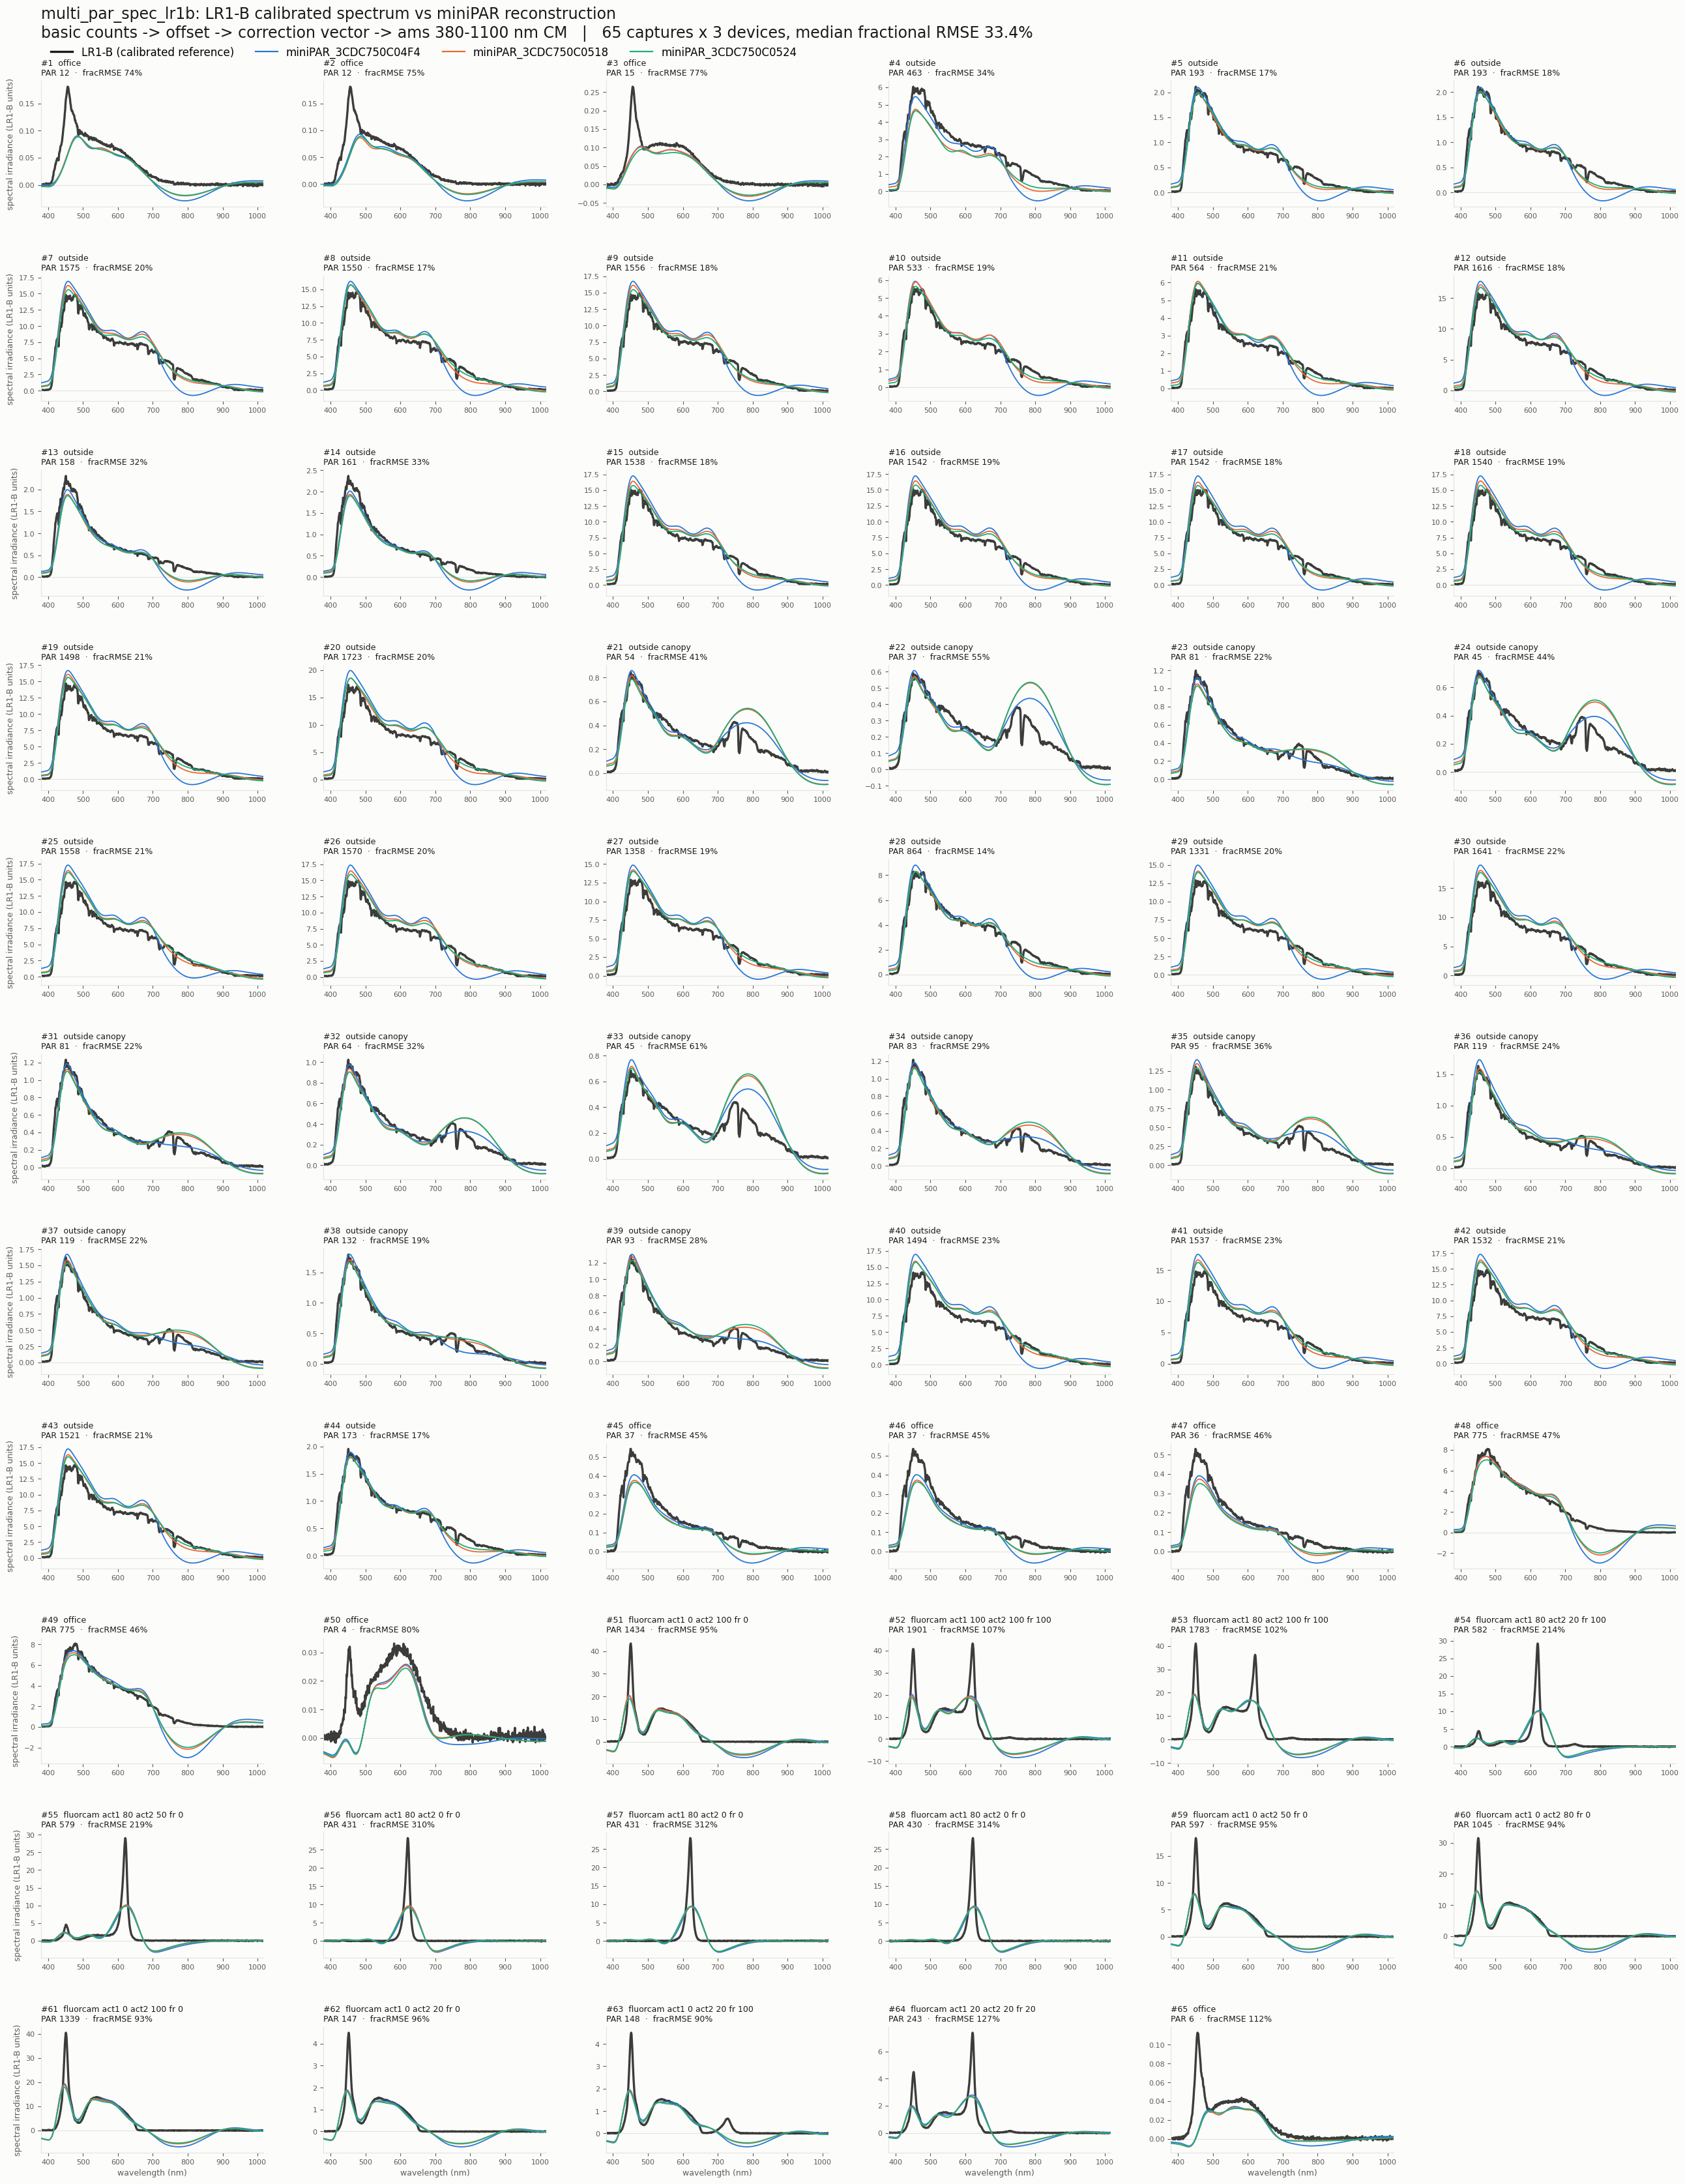

In [8]:
DEV_COLOR = dict(zip(devices, ['#2a78d6', '#eb6834', '#1baf7a']))   # validated categorical 1-3
SURFACE, INK, MUTED, GRID, REF = '#fcfcfb', '#1a1a19', '#5c5b55', '#e4e3dd', '#1a1a19'

meas = sorted(df.measurement.unique())
ncol = 6
nrow = int(np.ceil(len(meas) / ncol))
wl = cm_wv[overlap]

fig, axes = plt.subplots(nrow, ncol, figsize=(4.4 * ncol, 3.1 * nrow), facecolor=SURFACE)
fig.subplots_adjust(left=0.04, right=0.99, top=1 - 0.42 / nrow, bottom=0.03,
                    wspace=0.27, hspace=0.55)
fig.suptitle('multi_par_spec_lr1b: LR1-B calibrated spectrum vs miniPAR reconstruction\n'
             'basic counts -> offset -> correction vector -> ams 380-1100 nm CM   |   '
             + str(len(meas)) + ' captures x ' + str(len(devices)) + ' devices, '
             'median fractional RMSE ' + format(float(np.median(frac_rmse)), '.1f') + '%',
             fontsize=17, color=INK, x=0.04, ha='left', y=1 - 0.05 / nrow)

for ax, m in zip(axes.ravel(), meas):
    g = df[df.measurement == m]
    i0 = g.index[0]
    ax.set_facecolor(SURFACE)
    ax.plot(wl, E_all[i0][overlap], color=REF, lw=2.4, alpha=0.85,
            label='LR1-B (calibrated)', zorder=2)
    for idx, dev in zip(g.index, g.miniPAR):
        ax.plot(wl, reconstructed[idx][overlap], color=DEV_COLOR[dev], lw=1.3,
                label=dev, zorder=3)
    tag = g.metadata.iloc[0]
    tag = tag if len(tag) <= 34 else tag[:33] + '…'
    ax.set_title('#%d  %s\nPAR %.0f  ·  fracRMSE %.0f%%'
                 % (m, tag, g.tia_par.iloc[0], g.frac_rmse.median()),
                 fontsize=9, color=INK, loc='left', pad=6)
    ax.axhline(0, color=GRID, lw=0.8, zorder=1)
    ax.set_xlim(wl.min(), wl.max())
    ax.tick_params(colors=MUTED, labelsize=8)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(GRID)

for ax in axes.ravel()[len(meas):]:
    ax.set_visible(False)
for ax in axes[-1]:
    if ax.get_visible():
        ax.set_xlabel('wavelength (nm)', fontsize=9, color=MUTED)
for row in axes:
    row[0].set_ylabel('spectral irradiance (LR1-B units)', fontsize=9, color=MUTED)

handles = ([plt.Line2D([], [], color=REF, lw=2.4, label='LR1-B (calibrated reference)')]
           + [plt.Line2D([], [], color=c, lw=1.6, label=d) for d, c in DEV_COLOR.items()])
fig.legend(handles=handles, frameon=False, fontsize=12, ncol=4,
           loc='upper left', bbox_to_anchor=(0.04, 1 - 0.20 / nrow))
plt.show()

## Reading the result

- The reconstruction tracks the reference **in shape** (median correlation ≈ 0.97) but not
  closely in magnitude across the band (median fractional RMSE ≈ 28 %). That is the expected
  performance of a **Type** calibration: the CM is a Golden-Device matrix, and the only
  device-specific freedom in the whole chain is the 10-element correction vector.
- The correction vectors agree to a few percent across the three units, which is the useful
  device-to-device result: the parts are consistent, and a shared CM plus a per-device vector is
  a defensible configuration.
- **The offsets are ams typicals**, not measured on these parts. They are only 0.08–0.61 % of the
  median signal here, so they barely move this fit — but they matter at low light, and this set
  reaches PAR 3.7. Replace `OFFSET_BASIC` once a dark sweep exists.
- 1018–1100 nm is excluded everywhere: the LR1-B stops at 1017.5 nm, so those CM rows have no
  reference behind them. Reconstructed values there are extrapolation and are not plotted.
- Geometry is uncorrected. The LR1-B input optic and the miniPAR diffuser have different angular
  responses, so the comparison is cleanest under uniform diffuse illumination and least clean on
  the directional outdoor captures.
- PAR is deliberately absent. Once the reconstruction is trusted it is a photon integral over
  400–700 nm of the reconstructed spectrum, with no fitted scalar and no negative coefficients.